In [2]:
import json
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from scikit_posthocs import posthoc_tukey
from statannotations.Annotator import Annotator 

os.chdir('/rds/user/mf774/hpc-work/part_II_project/hovernet/hovernet-conic/inference-results/final-test-inference/')

MODEL = "lizard"
# select from "lizard", "CD3" or "CK"

name_disease_map = {
    'PS23-09764': "normal",
    'PS23-09872': "normal",
    'PS23-10343': "normal",
    'PS23-10347': "normal",
    'PS23-10398': "normal",
    'PS23-10404': "normal",
    'PS23-10411': "normal",
    'PS23-10437': "normal",
    'PS23-10439': "normal",
    'PS23-10441': "normal",
    'PS23-10445': "normal",
    'PS23-10452': "normal",
    'PS23-10137': "normal",
    'PS23-10155': "normal",
    'PS23-12147': "normal",
    'PS23-14038': "coeliac",
    'PS23-14197': "coeliac",
    'PS23-14780': "coeliac",
    'PS23-14976': "coeliac",
    'PS23-15233': "coeliac",
    'PS23-15567': "coeliac",
    'PS23-15579': "coeliac",
    'PS23-16462': "coeliac",
    'PS23-16587': "coeliac",
    'PS23-17229': "coeliac",
    'PS23-17985': "coeliac",
    'PS23-18010': "coeliac",
    'PS23-18011': "coeliac",
    'PS23-19842': "coeliac",
    'PS23-20169': "coeliac",
    'PS23-20460': "NET",
    'PS23-21961': "NET",
    'PS23-14104': "adenocarcinoma",
    'PS23-19454': "adenocarcinoma",
    'PS23-10136': "adenoma",
    'PS23-14152': "adenoma",
    'PS23-14255': "adenoma",
    'PS23-15273': "adenoma",
    'PS23-19293': "adenoma",
    'PS23-18096': "ulcer",
    'PS23-29449': "ulcer",
}

In [3]:
### create density diagnosis csv

INPUT_CSV = f'summary_{MODEL}.csv'
OUTPUT_CSV = f'summary_{MODEL}_density_diagnosis.csv'
PATH_ROOT = '/rds/user/mf774/hpc-work/part_II_project/in-house/inference-data/'

def get_area_from_metadata(directory):
    diagnosis = name_disease_map[directory]
    if diagnosis == "NET" or diagnosis == "adenocarcinoma" or diagnosis == "adenoma" or diagnosis == "ulcer":
        diagnosis = "other"
    directory_path = f'{PATH_ROOT}/{diagnosis}/{directory}/'
    subdirectory_path = os.listdir(directory_path)[0]
    metadata_path = os.path.join(directory_path, subdirectory_path, 'metadata.json')
    with open(metadata_path, "r") as f:
        metadata = json.load(f)
    area = metadata["tissue_area_og_mask"]
    return area

def get_stain_area_density_diagnosis(input_csv, output_csv):
    
    diagnoses = {"diagnosis": []}
    areas = {"area": []}

    # get area and diagnosis
    df = pd.read_csv(input_csv)
    wsis = list(df["wsi"])
    for wsi in wsis:
        diagnoses["diagnosis"].append(name_disease_map[wsi])
        areas["area"].append(get_area_from_metadata(wsi))
    diagnoses = pd.DataFrame(diagnoses)
    areas = pd.DataFrame(areas)
    df['diagnosis'] = diagnoses
    df['area'] = areas

    # calculate nuclei density 
    if MODEL == 'lizard':
        df['total_cell_density'] = (df['total_cells'] / df['area']) * 1000
        df['neutrophil_density'] = (df['neutrophil'] / df['area']) * 1000
        df['epithelial_density'] = (df['epithelial'] / df['area']) * 1000
        df['lymphocyte_density'] = (df['lymphocyte'] / df['area']) * 1000
        df['plasma_density'] = (df['plasma'] / df['area']) * 1000
        df['eosinophil_density'] = (df['eosinophil'] / df['area']) * 1000
        df['connective_density'] = (df['connective'] / df['area']) * 1000
    else:
        df['positive_cell_density'] = (df['positive_cells'] / df['area']) * 1000 
        df['negative_cell_density'] = (df['negative_cells'] / df['area']) * 1000
        df['total_cell_density'] = (df["total_cells"] / df['area']) * 1000
    df.to_csv(output_csv, index=False)
    print(f"Processed data saved to {output_csv}")
    return

# calculate_cell_densities(INPUT_CSV, OUTPUT_CSV)
get_stain_area_density_diagnosis(INPUT_CSV, OUTPUT_CSV)

Processed data saved to summary_lizard_density_diagnosis.csv


/tmp/ipykernel_3035290/4250690077.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

adenoma vs. ulcer: Custom statistical test, P_val:4.054e-02
NET vs. adenocarcinoma: Custom statistical test, P_val:2.322e-02
normal vs. adenoma: Custom statistical test, P_val:3.664e-02
adenoma vs. adenocarcinoma: Custom statistical test, P_val:8.491e-04
coeliac vs. adenocarcinoma: Custom statistical test, P_val:2.777e-03


/tmp/ipykernel_3035290/4250690077.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

adenoma vs. NET: Custom statistical test, P_val:4.014e-02
ulcer vs. adenocarcinoma: Custom statistical test, P_val:6.651e-04
coeliac vs. NET: Custom statistical test, P_val:1.175e-02
adenoma vs. adenocarcinoma: Custom statistical test, P_val:4.129e-06
normal vs. NET: Custom statistical test, P_val:1.784e-03
coeliac vs. adenocarcinoma: Custom statistical test, P_val:2.369e-07
normal vs. adenocarcinoma: Custom statistical test, P_val:3.329e-08


/tmp/ipykernel_3035290/4250690077.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')


...

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

normal vs. coeliac: Custom statistical test, P_val:1.942e-02


/tmp/ipykernel_3035290/4250690077.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

normal vs. coeliac: Custom statistical test, P_val:3.408e-02
coeliac vs. adenocarcinoma: Custom statistical test, P_val:1.622e-02


/tmp/ipykernel_3035290/4250690077.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_3035290/4250690077.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

coeliac vs. adenoma: Custom statistical test, P_val:3.796e-03
adenoma vs. adenocarcinoma: Custom statistical test, P_val:2.830e-02


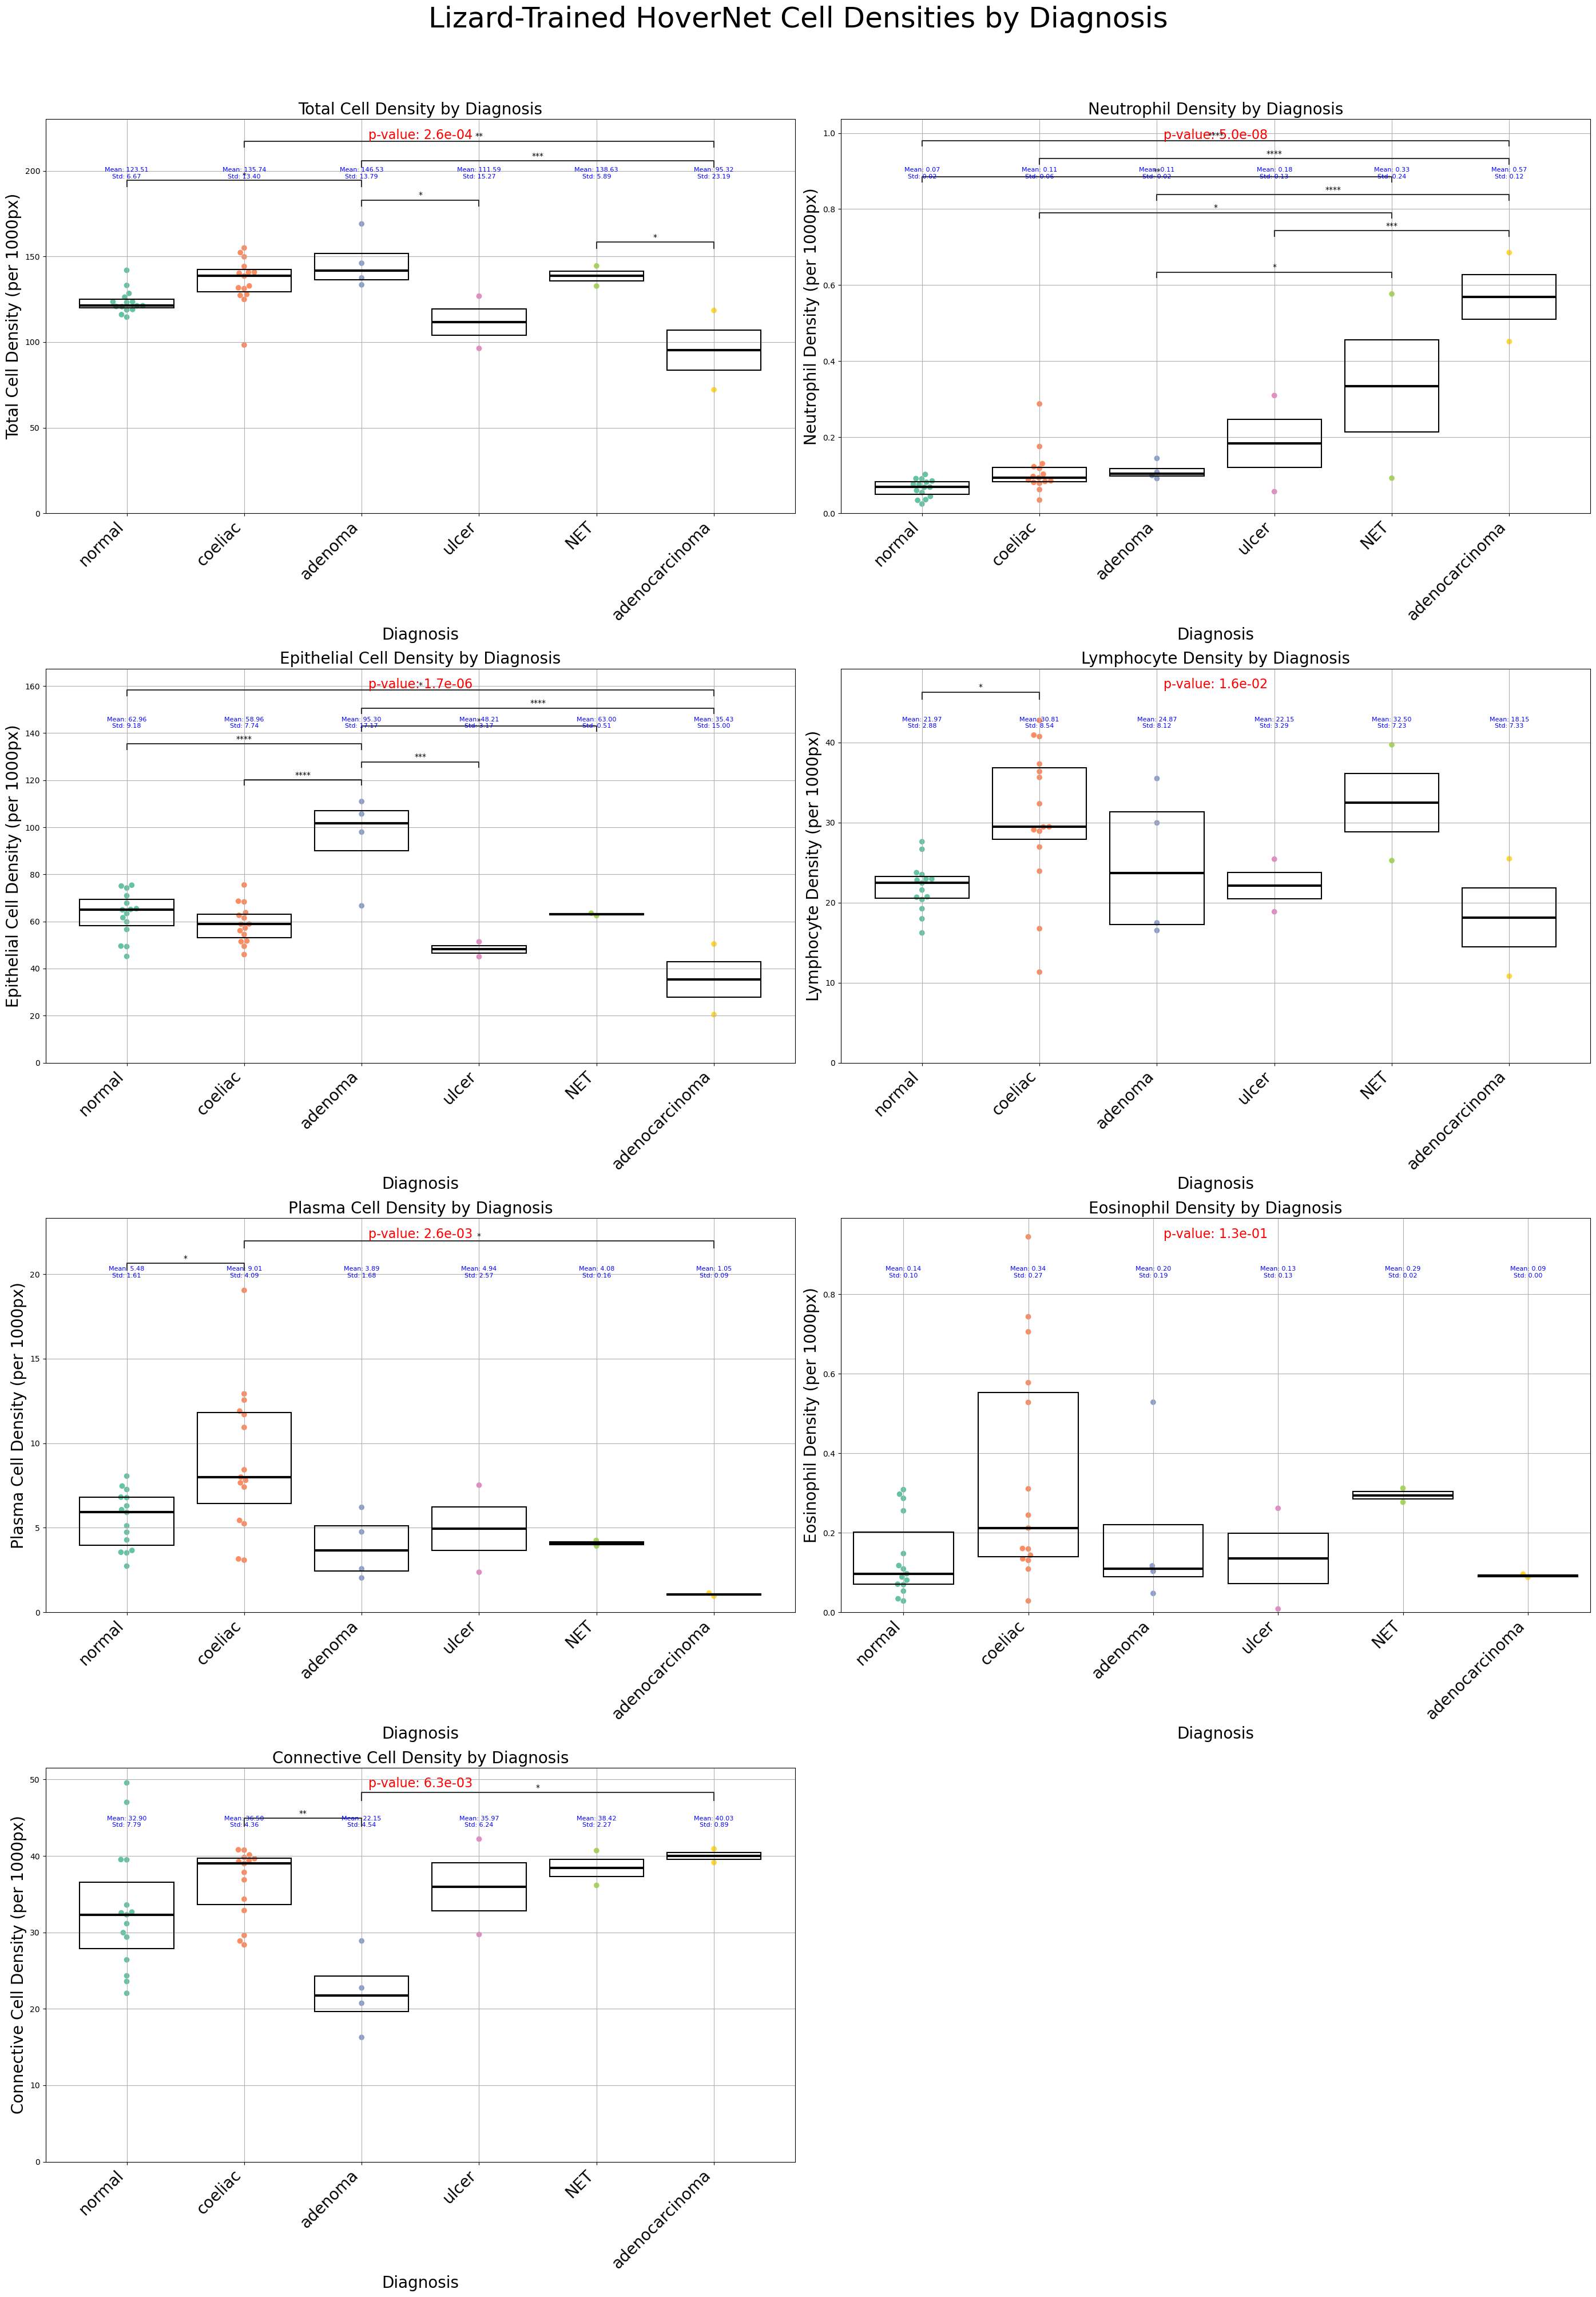

In [3]:
### produce summary scatterplots

file_path = f"summary_{MODEL}_density_diagnosis.csv"
data = pd.read_csv(file_path)

# Define function to generate plots
def plot_data(subset_data, cell_type):
    
    if MODEL == "lizard":
        metrics = ["total_cell_density", "neutrophil_density", "epithelial_density", "lymphocyte_density", "plasma_density", "eosinophil_density", "connective_density"]
        metric_names = ["Total Cell Density (per 1000px)", "Neutrophil Density (per 1000px)" , "Epithelial Cell Density (per 1000px)", "Lymphocyte Density (per 1000px)", "Plasma Cell Density (per 1000px)", "Eosinophil Density (per 1000px)", "Connective Cell Density (per 1000px)"]
        plot_titles = ["Total Cell Density by Diagnosis", "Neutrophil Density by Diagnosis", "Epithelial Cell Density by Diagnosis", "Lymphocyte Density by Diagnosis", "Plasma Cell Density by Diagnosis", "Eosinophil Density by Diagnosis", "Connective Cell Density by Diagnosis"]
        fig, axes = plt.subplots(4, 2, figsize=(28, 40))
        plt.suptitle(f'{MODEL.capitalize()}-Trained HoverNet Cell Densities by Diagnosis', fontsize=36, y=1.0025)
    elif MODEL == "CD3":
        metrics = ["total_cell_density", "positive_cell_density", "negative_cell_density"]
        metric_names = ["Total Cell Density (per 1000px)", "T Cell Density (per 1000px) ", "Non T Cell Density (per 1000px)"]
        plot_titles = ["Total Cell Density by Diagnosis", "T Cell Density by Diagnosis", "Non T Cell Density by Diagnosis"]
        fig, axes = plt.subplots(2, 2, figsize=(28, 20))
        plt.suptitle(f'{MODEL}-Trained HoverNet Cell Densities by Diagnosis', fontsize=36, y=1.0025)
    elif MODEL == "CK":
        metrics = ["total_cell_density", "positive_cell_density", "negative_cell_density"]
        metric_names = ["Total Cell Density (per 1000px)", "CK Cell Density (per 1000px) ", "Non CK Cell Density (per 1000px)"]
        plot_titles = ["Total Cell Density by Diagnosis", "CK Cell  Density by Diagnosis", "Non CK Cell Density by Diagnosis"]
        fig, axes = plt.subplots(2, 2, figsize=(28, 20))
        plt.suptitle(f'{MODEL}-Trained HoverNet Cell Densities by Diagnosis', fontsize=36, y=1.0025)
    else:
        print("Invalid model name. Please use 'lizard', 'CD3', or 'CK'.")
        return
    
    groups = subset_data['diagnosis'].unique()
    axes = axes.flatten()

    tukey_results ={}

    for idx, metric in enumerate(metrics):
        sns.swarmplot(ax=axes[idx], x='diagnosis', y=metric, data=subset_data, hue='diagnosis', palette="Set2", size=7, alpha=1, zorder=1)
        sns.boxplot(ax=axes[idx], x='diagnosis', y=metric, data=subset_data, showmeans=False, meanline=False,
                    showfliers=False, whiskerprops={'visible': False}, capprops={'visible': False},
                    medianprops={'color': 'black', 'linewidth': 3, 'zorder': 2},
                    boxprops={'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.5, 'zorder': 2})

        axes[idx].set_title(plot_titles[idx], fontsize=20)
        axes[idx].set_xlabel('Diagnosis', fontsize=20)
        axes[idx].set_ylabel(metric_names[idx], fontsize=20)
        axes[idx].grid(True)
        axes[idx].set_ylim(bottom=0)

        for label in axes[idx].get_xticklabels():
            label.set_fontsize(20)
            
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

        # ANOVA test
        group_data = [subset_data[subset_data['diagnosis'] == group][metric] for group in groups]
        f_stat, p_value = f_oneway(*group_data)

        # tukey_hsd test
        
        # code from https://blog.4dcu.be/programming/2021/12/30/Posthoc-Statannotations.html
        tukey_df = posthoc_tukey(subset_data, val_col=metric, group_col="diagnosis")
        remove = np.tril(np.ones(tukey_df.shape), k=0).astype("bool")
        tukey_df[remove] = np.nan
        molten_df = tukey_df.melt(ignore_index=False).reset_index().dropna()
        pairs = [(i[1]["index"], i[1]["variable"]) for i in molten_df.iterrows()]
        p_values = [i[1]["value"] for i in molten_df.iterrows()]
        
        # Annotator for Tukey HSD test, display only significant p-values
        significant_pairs = [(pair, p) for pair, p in zip(pairs, p_values) if p < 0.05]  # Only keep significant pairs
        significant_p_values = [p for p in p_values if p < 0.05]  # Only keep significant p-values
        
        # Ensure valid diagnosis categories in pairs
        valid_pairs = []
        valid_p_values = []

        # Filter out invalid pairs where one or both diagnoses are missing in the data
        for pair, p in significant_pairs:
            if all(diagnosis in subset_data['diagnosis'].values for diagnosis in pair):
                valid_pairs.append(pair)
                valid_p_values.append(p)
        
        if valid_p_values:  # If there are significant p-values, add annotations
            annotator = Annotator(
                axes[idx], valid_pairs, data=subset_data, x="diagnosis", y=metric, zorder=1
            )
            annotator.configure(text_format="star", loc="inside")
            annotator.set_pvalues_and_annotate(valid_p_values)
        
    
        axes[idx].annotate(f'p-value: {p_value:.1e}', xy=(0.5, 0.95), xycoords='axes fraction',
                           ha='center', fontsize=16, color='red')
        
        # Calculate and display mean and std for each group
        for group in groups:
            group_data = subset_data[subset_data['diagnosis'] == group][metric]
            mean = np.mean(group_data)
            std = np.std(group_data)

            # Display mean and std on the plot (at the position of the group on the x-axis)
            x_pos = np.where(groups == group)[0][0]  # Find x position for the group
            axes[idx].text(x_pos, axes[idx].get_ylim()[1] * 0.85,  # Position above the plot
                        f'Mean: {mean:.2f}\nStd: {std:.2f}',
                        ha='center', fontsize=8, color='blue')
        
        tukey_results[metric] = tukey_df

    for j in range(len(metrics), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout(rect=[0,0,1,0.98])
    plt.savefig(f'scatterplot_{cell_type}.png')
    plt.show()
    
    return tukey_results

tukey_df = plot_data(data, MODEL)

In [6]:
### p-values from tukey-hsd

# convert each df with tukey_df dictionary to dataframe
for metric in tukey_df.keys():
    df = tukey_df[metric]
    print(df.head())


         normal   coeliac   adenoma     ulcer       NET  adenocarcinoma
normal      NaN  0.130356  0.036641  0.823937  0.637503        0.067842
coeliac     NaN       NaN  0.681075  0.161325  0.999666        0.002777
adenoma     NaN       NaN       NaN  0.040542  0.980424        0.000849
ulcer       NaN       NaN       NaN       NaN  0.319823        0.807652
NET         NaN       NaN       NaN       NaN       NaN        0.023221
         normal   coeliac   adenoma     ulcer       NET  adenocarcinoma
normal      NaN  0.712321  0.928835  0.434976  0.001784    3.328908e-08
coeliac     NaN       NaN  1.000000  0.841934  0.011747    2.368947e-07
adenoma     NaN       NaN       NaN  0.911996  0.040144    4.129110e-06
ulcer       NaN       NaN       NaN       NaN  0.466062    6.651490e-04
NET         NaN       NaN       NaN       NaN       NaN    7.877557e-02
         normal   coeliac   adenoma     ulcer       NET  adenocarcinoma
normal      NaN  0.903128  0.000066  0.448614  1.000000        0

In [57]:
# setup for all binary classification approaches

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, precision_recall_curve, auc, roc_auc_score

df = pd.read_csv(f"summary_{MODEL}_density_diagnosis.csv")

# Select features
if MODEL == "lizard":
    features = ["total_cell_density", "neutrophil_density", "epithelial_density", "lymphocyte_density", "plasma_density", "eosinophil_density", "connective_density"]
    all_features = df[features]
    total_cell_density = df["total_cell_density"]
    neutrophil_density = df["neutrophil_density"]
    epithelial_density = df["epithelial_density"]
    lymphocyte_density = df["lymphocyte_density"]
    plasma_density = df["plasma_density"]
    eosinophil_density = df["eosinophil_density"]
    connective_density = df["connective_density"]
else:
    features = ["total_cell_density", "pos_cell_density", "neg_cell_density"]
    all_features = df[features]
    total_cell_density = df["total_cell_density"]
    pos_cell_density = df["pos_cell_density"]
    neg_cell_density = df["neg_cell_density"]

target = "diagnosis"
y = df[target].apply(lambda x: 0 if x.lower() == "normal" else 1)
sc = StandardScaler()
all_features = sc.fit_transform(all_features)

Logistic Regression Model
Overall Accuracy: 0.7000
Precision: 0.6154
Recall: 0.5333
Negative Predictive Value: 0.7407
Specificity: 0.8000
Normal F1 Score: 0.5714
Pathology F1 Score: 0.7692


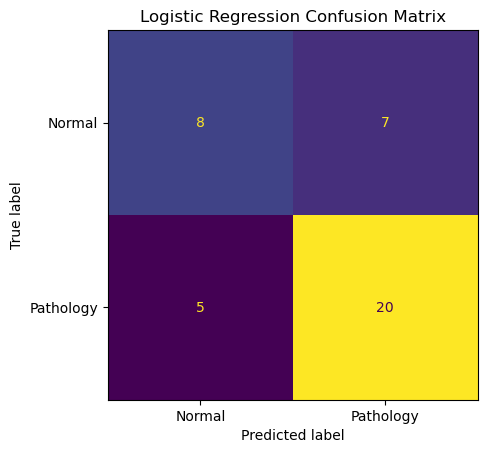

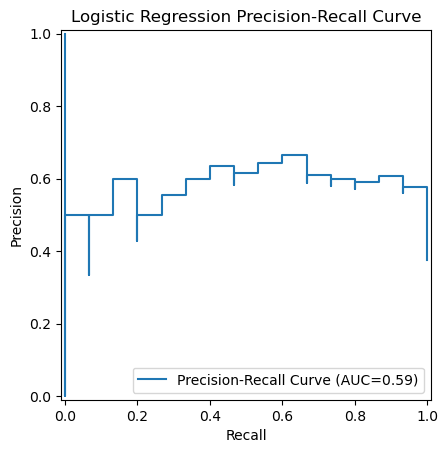

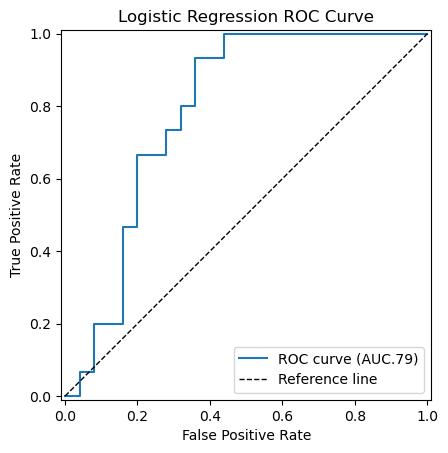

In [152]:
### 5 fold cross validation logistic regression all features

log_reg = LogisticRegression(random_state=42)
reg_y_pred = cross_val_predict(log_reg, all_features, y, cv=5)
reg_y_probs = cross_val_predict(log_reg, all_features, y, cv=5, method="predict_proba")
reg_accuracy = accuracy_score(y, reg_y_pred)
reg_precision, reg_recall, reg_f1, _ = precision_recall_fscore_support(y, reg_y_pred, labels=[0,1])

# defining normal as the positive class
print(f"Logistic Regression Model")
print(f"Overall Accuracy: {reg_accuracy:.4f}")
print(f"Precision: {reg_precision[0]:.4f}")
print(f"Recall: {reg_recall[0]:.4f}")
print(f"Negative Predictive Value: {reg_precision[1]:.4f}") # precision of the negative class is the same as NPV
print(f"Specificity: {reg_recall[1]:.4f}") # recall of the negative class is the same as specificity
print(f"Normal F1 Score: {reg_f1[0]:.4f}")
print(f"Pathology F1 Score: {reg_f1[1]:.4f}")

reg_y_probs = cross_val_predict(log_reg, all_features, y, cv=5, method="predict_proba")

# confusion matrix
reg_cm = confusion_matrix(y, reg_y_pred)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=reg_cm, display_labels=["Normal", "Pathology"])
disp_cm.plot(colorbar=False)
plt.title("Logistic Regression Confusion Matrix")
plt.savefig("logistic_regression_cm.png", dpi=300)
plt.show()

# precision-recall graph
# cannot quite work out how to calculate auc (however when I don't change the label it does it for me. Therefore set AUC=0.59)
disp_pr = PrecisionRecallDisplay.from_predictions(y, reg_y_probs_normal, pos_label=0, label="Precision-Recall Curve (AUC=0.59)")
plt.title("Logistic Regression Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower right")
plt.savefig("logistic_regression_pr.png", dpi=300)
plt.show()

# roc-auc graph
reg_y_probs_normal = reg_y_probs[:, 0]
# cannot quite work out how to calculate roc_auc (however when I don't change the label it does it for me. Therefore set AUC=0.79)
RocCurveDisplay.from_predictions(y, reg_y_probs_normal, pos_label=0, label="ROC curve (AUC.79)")
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', label="Reference line")
plt.title(f"Logistic Regression ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig("logistic_regression_roc.png", dpi=300)
plt.show()

# pca with decision boundary - extract percentage of variance explained by each component

In [56]:
### 5 fold cross validation random forest all features

rand_forest = RandomForestClassifier(random_state=42, n_estimators=10000)
rand_forest_y_pred = cross_val_predict(rand_forest, all_features, y, cv=5)
rand_forest_accuracy = accuracy_score(y, rand_forest_y_pred)
rand_forest_precision, rand_forest_recall, rand_forest_f1, _ = precision_recall_fscore_support(y, rand_forest_y_pred, labels=[0,1])

print(f"Random Forest Model")
print(f"Overall Accuracy: {rand_forest_accuracy:.4f}")
print(f"Precision: {rand_forest_precision[0]:.4f}")
print(f"Recall: {rand_forest_recall[0]:.4f}")
print(f"Negative Predictive Value: {rand_forest_precision[1]:.4f}") # negative predictive value is the same as precision for the negative class
print(f"Specificity: {rand_forest_recall[1]:.4f}") # specificity is the same as recall for the negative class
print(f"Normal F1 Score: {rand_forest_f1[0]:.4f}")
print(f"Pathology F1 Score: {rand_forest_f1[1]:.4f}")

Random Forest Model
Overall Accuracy: 0.8250
Precision: 0.7500
Recall: 0.8000
Negative Predictive Value: 0.8750
Specificity: 0.8400
Normal F1 Score: 0.7742
Pathology F1 Score: 0.8571


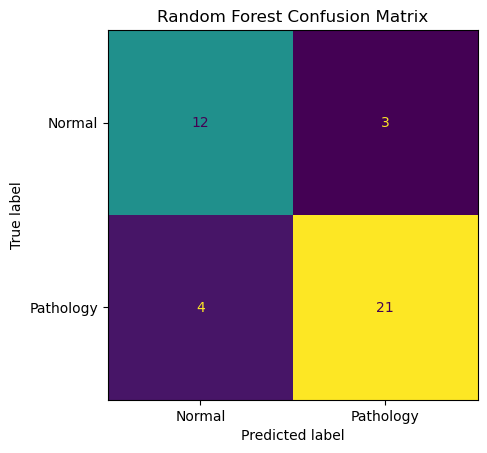

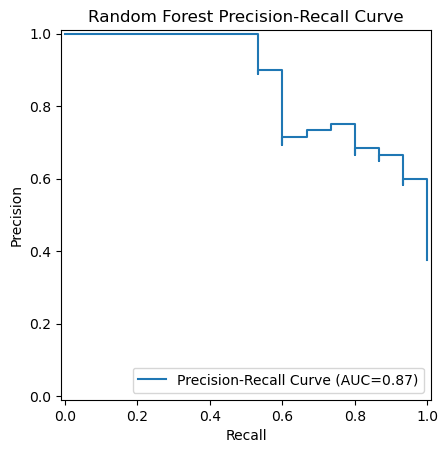

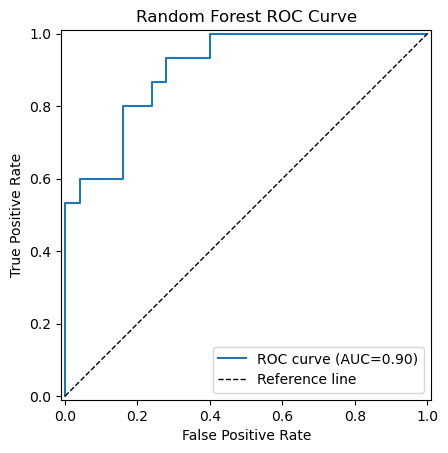

In [156]:
rand_forest_y_probs = cross_val_predict(rand_forest, all_features, y, cv=5, method="predict_proba")
rand_forest_y_probs_normal = rand_forest_y_probs[:, 0]

# confusion matrix
reg_cm = confusion_matrix(y, rand_forest_y_pred)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=reg_cm, display_labels=["Normal", "Pathology"])
disp_cm.plot(colorbar=False)
plt.title("Random Forest Confusion Matrix")
plt.savefig("random_forest_cm.png", dpi=300)
plt.show()

# precision-recall graph
# cannot quite work out how to calculate roc_auc (however when I don't change the label it does it for me. Therefore set AUC=0.87)
disp_pr = PrecisionRecallDisplay.from_predictions(y, rand_forest_y_probs_normal, pos_label=0, label="Precision-Recall Curve (AUC=0.87)")
plt.title("Random Forest Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower right")
plt.savefig("random_forest_pr.png", dpi=300)
plt.show()

# roc-auc graph
rand_forest_y_probs_normal = rand_forest_y_probs[:, 0]
# cannot quite work out how to calculate roc_auc (however when I don't change the label it does it for me. Therefore set AUC=0.90)
RocCurveDisplay.from_predictions(y, rand_forest_y_probs_normal, pos_label=0, label="ROC curve (AUC=0.90)")
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', label="Reference line")
plt.title(f"Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc = "lower right")
plt.savefig("random_forest_roc.png", dpi=300)
plt.show()

In [157]:
### 5-fold cross validation random forest single feature

# Assume your features are pandas Series
features = {
    'all_features': all_features,
    'total_cell_density': total_cell_density,
    'neutrophil_density': neutrophil_density,
    'epithelial_density': epithelial_density,
    'lymphocyte_density': lymphocyte_density,
    'plasma_density': plasma_density,
    'eosinophil_density': eosinophil_density,
    'connective_density': connective_density
}

sc = StandardScaler()

# Standardize all features
for key in features:
    if features[key].ndim == 1:
        features[key] = sc.fit_transform(features[key].values.reshape(-1, 1))
    else:
        features[key] = sc.fit_transform(features[key])

results = []
for feature_name, feature_data in features.items():
    print(f"\n=== Random Forest Using '{feature_name}' ===")

    rand_forest = RandomForestClassifier(random_state=42, n_estimators=10000)
    y_pred = cross_val_predict(rand_forest, feature_data, y, cv=5)

    accuracy = accuracy_score(y, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y, y_pred, labels=[0, 1])

    metrics = {
        'accuracy': accuracy,
        'precision': precision[0],
        'recall': recall[0],
        'NPV': precision[1], # negative predictive value is the same as precision for the negative class
        'specificity': recall[1], # specificity is the same as recall for the negative class
        'normal F1 score': f1[0],
        'pathology F1 score': f1[1],
    }

    for metric_name, value in metrics.items():
        results.append({
            'feature': feature_name,
            'metric': metric_name,
            'value': value
        })

    print(f"Overall Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision[0]:.4f}")
    print(f"Recall: {recall[0]:.4f}")
    print(f"Negative Predictive Value: {precision[1]:.4f}")
    print(f"Specificity: {recall[1]:.4f}")
    print(f"Normal F1 Score: {f1[0]:.4f}")
    print(f"Pathology F1 Score: {f1[1]:.4f}")

df_results = pd.DataFrame(results)


=== Random Forest Using 'all_features' ===
Overall Accuracy: 0.8250
Precision: 0.7500
Recall: 0.8000
Negative Predictive Value: 0.8750
Specificity: 0.8400
Normal F1 Score: 0.7742
Pathology F1 Score: 0.8571

=== Random Forest Using 'total_cell_density' ===
Overall Accuracy: 0.8250
Precision: 0.7857
Recall: 0.7333
Negative Predictive Value: 0.8462
Specificity: 0.8800
Normal F1 Score: 0.7586
Pathology F1 Score: 0.8627

=== Random Forest Using 'neutrophil_density' ===
Overall Accuracy: 0.6750
Precision: 0.5625
Recall: 0.6000
Negative Predictive Value: 0.7500
Specificity: 0.7200
Normal F1 Score: 0.5806
Pathology F1 Score: 0.7347

=== Random Forest Using 'epithelial_density' ===
Overall Accuracy: 0.4750
Precision: 0.2857
Recall: 0.2667
Negative Predictive Value: 0.5769
Specificity: 0.6000
Normal F1 Score: 0.2759
Pathology F1 Score: 0.5882

=== Random Forest Using 'lymphocyte_density' ===
Overall Accuracy: 0.8000
Precision: 0.7333
Recall: 0.7333
Negative Predictive Value: 0.8400
Specificity:

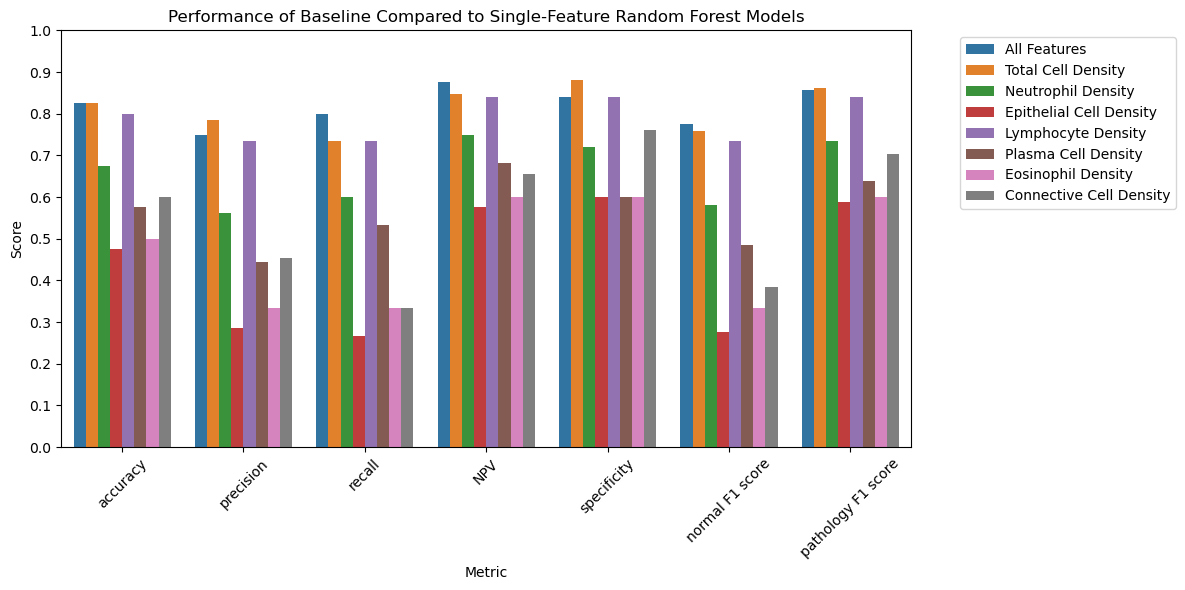

In [178]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x="metric", y="value", hue="feature")
plt.title("Performance of Baseline Compared to Single-Feature Random Forest Models")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1.00)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=45)
handles, labels = plt.gca().get_legend_handles_labels()
labels = ["All Features", "Total Cell Density", "Neutrophil Density", "Epithelial Cell Density", "Lymphocyte Density", "Plasma Cell Density", "Eosinophil Density", "Connective Cell Density"]
plt.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"single_feature_random_forest.png", dpi=300)
plt.show()

In [ ]:
# setup for all binary classification approaches

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

df = pd.read_csv(f"summary_{MODEL}_density_diagnosis.csv")

# Select features
if MODEL == "lizard":
    features = ["total_cell_density", "neutrophil_density", "epithelial_density", "lymphocyte_density", "plasma_density", "eosinophil_density", "connective_density"]
    all_features = df[features]
    total_cell_density = df["total_cell_density"]
    neutrophil_density = df["neutrophil_density"]
    epithelial_density = df["epithelial_density"]
    lymphocyte_density = df["lymphocyte_density"]
    plasma_density = df["plasma_density"]
    eosinophil_density = df["eosinophil_density"]
    connective_density = df["connective_density"]
else:
    features = ["total_cell_density", "pos_cell_density", "neg_cell_density"]
    all_features = df[features]
    total_cell_density = df["total_cell_density"]
    pos_cell_density = df["pos_cell_density"]
    neg_cell_density = df["neg_cell_density"]

target = "diagnosis"
y = df[target].apply(lambda x: 0 if x.lower() == "normal" else 1)
sc = StandardScaler()
all_features = sc.fit_transform(all_features)

log_reg = LogisticRegression(random_state=42)
reg_y_pred = cross_val_predict(log_reg, all_features, y, cv=5)
reg_accuracy = accuracy_score(y, y_pred)
reg_precision, reg_recall, reg_f1, _ = precision_recall_fscore_support(y, y_pred, average='binary', pos_label=0)
reg_cm = confusion_matrix(y, reg_y_pred)
reg_tn, reg_fp, reg_fn, reg_tp = cm.ravel()
reg_specificity = tn / (tn + fp)
reg_npv = tn / (tn + fn)

# Print the metrics for both categories (0 and 1)

print(f"Logistic Regression Model")
print(f"Overall Accuracy: {reg_accuracy:.4f}")
print(f"Precision: {reg_precision:.4f}")
print(f"Recall: {reg_recall:.4f}")
print(f"Specificity: {reg_specificity:.4f}")
print(f"NPV: {reg_npv:.4f}")
print(f"F1 Score: {reg_f1:.4f}")

rand_forest = RandomForestClassifier(random_state=42, n_estimators=10000)
rand_forest_y_pred = cross_val_predict(rand_forest, all_features, y, cv=5)
rand_forest_accuracy = accuracy_score(y, rand_forest_y_pred)
rand_forest_precision, rand_forest_recall, rand_forest_f1, _ = precision_recall_fscore_support(y, rand_forest_y_pred, average='binary')

print(f"Random Forest Model")
print(f"Overall Accuracy: {rand_forest_accuracy:.4f}")
print(f"Precision for Normal: {rand_forest_precision[0]:.4f}")
print(f"Precision for Pathology: {rand_forest_precision[1]:.4f}")
print(f"Recall for Normal: {rand_forest_recall[0]:.4f}")
print(f"Recall for Pathology: {rand_forest_recall[1]:.4f}")
print(f"F1 Score for Normal: {rand_forest_f1[0]:.4f}")
print(f"F1 Score for Pathology: {rand_forest_f1[1]:.4f}")



total_cell_density =sc.fit_transform(total_cell_density.values.reshape(-1, 1))
neutrophil_density = sc.fit_transform(neutrophil_density.values.reshape(-1, 1))
epithelial_density = sc.fit_transform(epithelial_density.values.reshape(-1, 1))
lymphocyte_density = sc.fit_transform(lymphocyte_density.values.reshape(-1, 1))
plasma_density = sc.fit_transform(plasma_density.values.reshape(-1, 1))
eosinophil_density = sc.fit_transform(eosinophil_density.values.reshape(-1, 1))
connective_density = sc.fit_transform(connective_density.values.reshape(-1, 1))

In [160]:
### 5-fold cross validation logistic regression

log_reg = RandomForestClassifier(random_state=42, n_estimators=10000)
y_pred = cross_val_predict(log_reg, all_features, y, cv=5)
accuracy = accuracy_score(y, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y, y_pred, labels=[0, 1])

# Print the metrics for both categories (0 and 1)
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Precision for Normal: {precision[0]:.4f}")
print(f"Precision for Pathology: {precision[1]:.4f}")
print(f"Recall for Normal: {recall[0]:.4f}")
print(f"Recall for Pathology: {recall[1]:.4f}")
print(f"F1 Score for Normal: {f1[0]:.4f}")
print(f"F1 Score for Pathology: {f1[1]:.4f}")

Overall Accuracy: 0.8250
Precision for Normal: 0.7500
Precision for Pathology: 0.8750
Recall for Normal: 0.8000
Recall for Pathology: 0.8400
F1 Score for Normal: 0.7742
F1 Score for Pathology: 0.8571


In [ ]:
### 5-fold cross validation logistic regression with all features
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


# Load the data
df = pd.read_csv(f"summary_{MODEL}_density_diagnosis.csv")

# Select features and target
if MODEL == "lizard":
    features = ["total_cell_density", "neutrophil_density", "epithelial_density", "lymphocyte_density", "plasma_density", "eosinophil_density", "connective_density"]
else:
    features = ["pos_nuc_density", "neg_nuc_density", "total_nuc_density"]
target = "diagnosis"

X = df[features]
y = df[target].apply(lambda x: 0 if x.lower() == "normal" else 1)

# Set up classifier pipeline with scaling
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42))

# Stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics
metrics = {
    "accuracy": [],
    "recall": [],
    "precision": [],
    "f1": [],
    "specificity": []
}

y_true =[]
y_pred = []
# Run 5-fold CV
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    clf.fit(X_train, y_train)
    y_true.extend(y_test)
    y_pred.extend(clf.predict(X_test))

print(y_true)
print(y_pred)
# Calculate overall accuracy
accuracy = accuracy_score(y_true, y_pred)

# Calculate precision, recall, F1 score for both classes (0 and 1)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1])

# Calculate specificity for both classes (0 for normal, 1 for pathology)
# Specificity for class 0 (normal): TN / (TN + FP)
# Specificity for class 1 (pathology): TN / (TN + FP)
conf_matrix = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# Specificity for class 0 (normal)
specificity_class_0 = tn / (tn + fp) if (tn + fp) > 0 else 0
# Specificity for class 1 (pathology)
specificity_class_1 = tp / (tp + fn) if (tp + fn) > 0 else 0

# Print the metrics for both categories (0 and 1)
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Precision for Normal: {precision[0]:.4f}")
print(f"Precision for Pathology: {precision[1]:.4f}")
print(f"Recall for Normal: {recall[0]:.4f}")
print(f"Recall for Pathology: {recall[1]:.4f}")
print(f"F1 Score for Normal: {f1[0]:.4f}")
print(f"F1 Score for Pathology: {f1[1]:.4f}")
print(f"Specificity for Normal: {specificity_class_0:.4f}")
print(f"Specificity for Pathology: {specificity_class_1:.4f}")


[0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1]
[0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1]
Overall Accuracy: 0.7500
Precision for Normal: 0.6667
Precision for Pathology: 0.8000
Recall for Normal: 0.6667
Recall for Pathology: 0.8000
F1 Score for Normal: 0.6667
F1 Score for Pathology: 0.8000
Specificity for Normal: 0.6667
Specificity for Pathology: 0.8000


In [ ]:
### 5-fold cross validation random forest with all features
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Load the data
df = pd.read_csv(f"summary_{MODEL}_density_diagnosis.csv")

# Select features and target
if MODEL == "lizard":
    features = ["total_cell_density", "neutrophil_density", "epithelial_density", "lymphocyte_density", "plasma_density", "eosinophil_density", "connective_density"]
else:
    features = ["pos_nuc_density", "neg_nuc_density", "total_nuc_density"]
target = "diagnosis"

X = df[features]
y = df[target].apply(lambda x: 0 if x.lower() == "normal" else 1)

# Setup classifier and cross-validation
clf = RandomForestClassifier(random_state=42, class_weight='balanced')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics
metrics = {
    "accuracy": [],
    "recall": [],
    "precision": [],
    "f1": [],
    "specificity": []
}

# Run 5-fold cross-validation
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Confusion matrix: [[TN, FP], [FN, TP]]
    cm = confusion_matrix(y_test, y_pred)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    spec = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0

    # Save metrics
    metrics["accuracy"].append(acc)
    metrics["recall"].append(rec)
    metrics["precision"].append(prec)
    metrics["f1"].append(f1)
    metrics["specificity"].append(spec)

# Report average metrics
print("5-Fold Cross-Validation Results:")
for metric in metrics:
    mean = np.mean(metrics[metric])
    std = np.std(metrics[metric])
    print(f"{metric.capitalize()}: {mean:.3f} ± {std:.3f}")


5-Fold Cross-Validation Results:
Accuracy: 0.775 ± 0.122
Recall: 0.840 ± 0.150
Precision: 0.813 ± 0.099
F1: 0.820 ± 0.107
Specificity: 0.667 ± 0.211


In [ ]:
### Visualize Random Forest Trees
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import os

# Access the RandomForestClassifier inside the pipeline
forest = clf.named_steps["randomforest"]  # Use the correct step name here

# Create output directory
os.makedirs("forest_trees", exist_ok=True)

# Loop through all trees in the forest
for i, estimator in enumerate(forest.estimators_):
    plt.figure(figsize=(15, 8))
    plot_tree(estimator, feature_names=features, class_names=["class 0", "class 1"], filled=True, rounded=True)
    plt.title(f"Decision Tree {i}")
    plt.savefig(f"forest_trees/tree_{i}.png")
    plt.close()

print(f"Saved {len(forest.estimators_)} trees to the folder 'forest_trees'")


AttributeError: 'RandomForestClassifier' object has no attribute 'named_steps'

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv(f"summary_{MODEL}_density_diagnosis.csv")

# Select features and target
if MODEL == "lizard":
    features = ["total_cell_density", "neutrophil_density", "epithelial_density", "lymphocyte_density", "plasma_density", "eosinophil_density", "connective_density"]
else:
    features = ["total_cell_density", "pos_cell_density", "neg_cell_density"]
target = "diagnosis"

X = df[features]
y = df[target]

# Encode target labels
y = LabelEncoder().fit_transform(y)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7500
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       1.00      1.00      1.00         1
           3       0.57      1.00      0.73         4
           4       1.00      1.00      1.00         4
           5       0.00      0.00      0.00         1

    accuracy                           0.75        12
   macro avg       0.43      0.50      0.45        12
weighted avg       0.61      0.75      0.66        12



/home/mf774/miniconda3/envs/tiatoolbox/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mf774/miniconda3/envs/tiatoolbox/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mf774/miniconda3/envs/tiatoolbox/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

/home/mf774/miniconda3/envs/tiatoolbox/lib/python3.12/site-packages/sklearn/metrics/_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


Average Diagnostic Scores (5-fold CV):
accuracy  : 0.775 ± 0.146
precision : 0.893 ± 0.137
specificity: 0.800 ± 0.267
recall    : 0.760 ± 0.196
f1        : 0.798 ± 0.145
roc_auc   : 0.867 ± 0.126
Best fold index: 1
Best fold AUC: 1.000


/home/mf774/miniconda3/envs/tiatoolbox/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


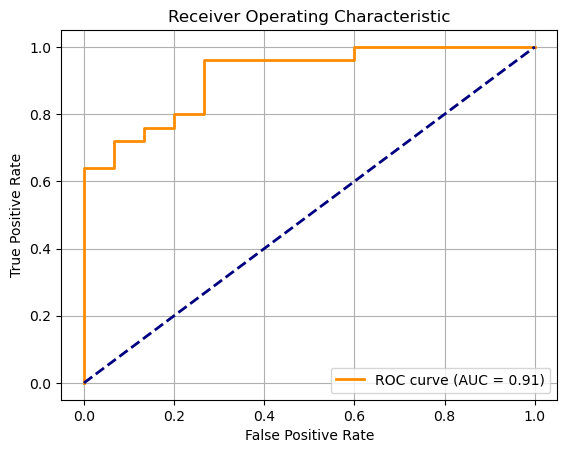

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix

MODEL = "lizard"
df = pd.read_csv(f"summary_{MODEL}_density_diagnosis.csv")

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Select features based on model type
if MODEL == "lizard":
    features = ["total_cell_density", "neutrophil_density", "epithelial_density", "lymphocyte_density",
                "plasma_density", "eosinophil_density", "connective_density"]
else:
    features = ["total_cell_density", "positive_cell_density", "negative_cell_density"]

# Select features and label
X = df[features]
y = df["diagnosis"].apply(lambda x: 0 if x.lower() == "normal" else 1)

# Create a pipeline with scaling and logistic regression with class balancing
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        class_weight='balanced',
        random_state=42,
        max_iter=1000,
        Cs=1000,
        cv=5,  # Inner CV for hyperparameter tuning
        scoring='roc_auc'
    )
)

# Define cross-validation strategy and metrics
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'specificity': make_scorer(specificity_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True)
}

# Perform cross-validation
scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_estimator=True)

# Report average scores
print("Average Diagnostic Scores (5-fold CV):")
for metric in scoring.keys():
    mean = scores[f'test_{metric}'].mean()
    std = scores[f'test_{metric}'].std()
    print(f"{metric:10s}: {mean:.3f} ± {std:.3f}")

# Plot ROC Curve from one of the folds (e.g., best-performing fold)
# Find the estimator with the highest AUC
best_idx = np.argmax(scores['test_roc_auc'])
print(f"Best fold index: {best_idx}")
print(f"Best fold AUC: {scores['test_roc_auc'][best_idx]:.3f}")
best_estimator = scores['estimator'][best_idx]

# Get probability predictions and true labels from that fold
X_scaled = StandardScaler().fit_transform(X)
y_prob = best_estimator.predict_proba(X_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Best C: 2.14947467343798
Accuracy: 0.9167
Classification Report:
              precision    recall  f1-score   support

      normal       0.83      1.00      0.91         5
   pathology       1.00      0.86      0.92         7

    accuracy                           0.92        12
   macro avg       0.92      0.93      0.92        12
weighted avg       0.93      0.92      0.92        12

Confusion Matrix:


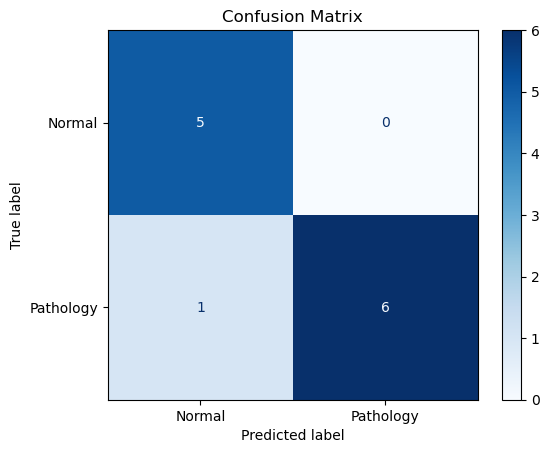

ROC Curve:


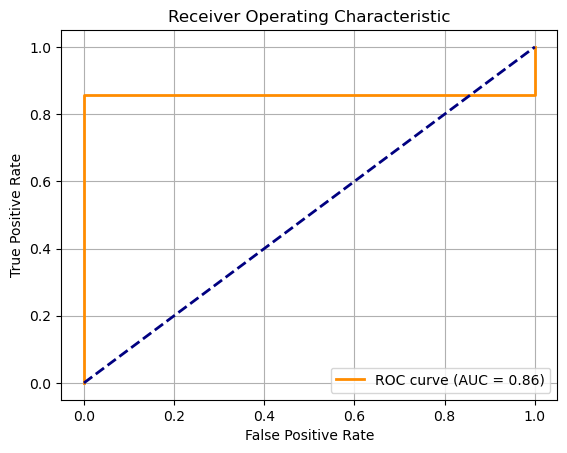

In [94]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve,  auc

# Load the dataset
df = pd.read_csv(f"summary_{MODEL}_density_diagnosis.csv")

# Select features based on model type
if MODEL == "lizard":
    features = ["total_cell_density", "neutrophil_density", "epithelial_density", "lymphocyte_density",
                "plasma_density", "eosinophil_density", "connective_density"]
else:
    features = ["total_cell_density", "positive_cell_density", "negative_cell_density"]

# select feature columns for binary classification
X = df[features]
# set diagnoses as either normal (0) or pathology (1)
y = df["diagnosis"].apply(lambda x: 0 if x.lower() == "normal" else 1)
# Split data into testing and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# Standardize data (z-score normalization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegressionCV(class_weight='balanced', random_state=42, max_iter=1000, Cs = 1000, cv=2, scoring='roc_auc')
model.fit(X_train, y_train)
print("Best C:", model.C_[0])

# Predict and evaluate model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["normal", "pathology"]))

print("Confusion Matrix:")
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=["Normal", "Pathology"], cmap='Blues')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

print("ROC Curve:")
# Compute ROC curve and AUC
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

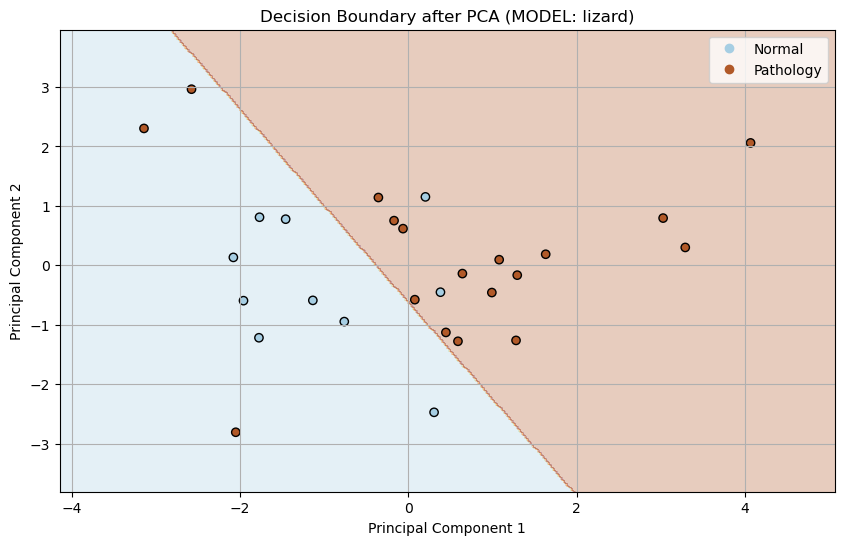

In [27]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Retrain logistic regression on PCA-reduced data
model_pca = LogisticRegression(class_weight='balanced', random_state=42)
model_pca.fit(X_train_pca, y_train)

# Create a mesh grid for decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predict probabilities over grid
Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.3)
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.Paired)

# Add legend
handles, labels = scatter.legend_elements()
plt.legend(handles, ["Normal", "Pathology"])
plt.title(f"Decision Boundary after PCA (MODEL: {MODEL})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


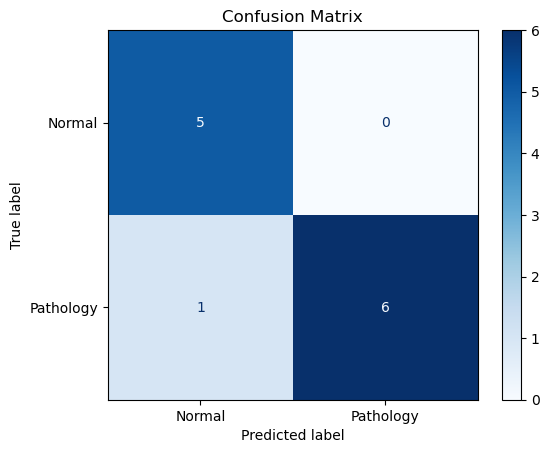

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=["Normal", "Pathology"], cmap='Blues')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


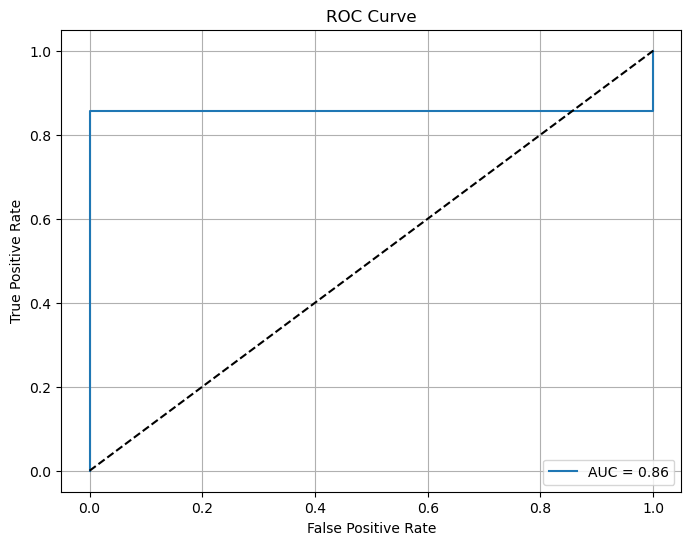

In [29]:
from sklearn.metrics import roc_curve, auc

y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


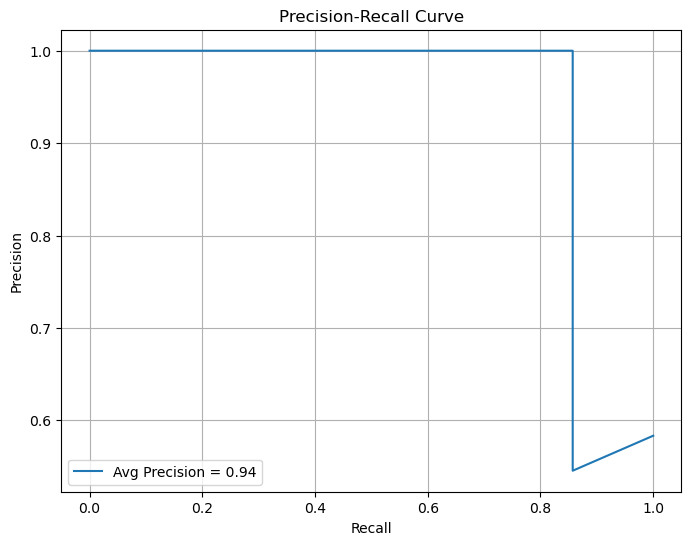

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"Avg Precision = {avg_precision:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.legend()
plt.show()


In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_with_const = add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

print(vif_data)

print(X.corr())


             Variable         VIF
0               const  248.374393
1  total_cell_density         inf
2  neutrophil_density         inf
3  epithelial_density         inf
4  lymphocyte_density         inf
5      plasma_density         inf
6  eosinophil_density         inf
7  connective_density         inf
                    total_cell_density  neutrophil_density  \
total_cell_density            1.000000           -0.322765   
neutrophil_density           -0.322765            1.000000   
epithelial_density            0.622991           -0.354247   
lymphocyte_density            0.685862            0.032685   
plasma_density                0.493688           -0.333735   
eosinophil_density            0.561280           -0.046889   
connective_density           -0.079238            0.147501   

                    epithelial_density  lymphocyte_density  plasma_density  \
total_cell_density            0.622991            0.685862        0.493688   
neutrophil_density           -0.354247   

In [42]:
import pandas as pd                                ## data analysis package
import matplotlib.pyplot as plt                    ## plot package
import warnings
warnings.filterwarnings("ignore")                
import statsmodels.formula.api as smf             
import statsmodels.api as sm                       ## statistical model package
from sklearn.metrics import confusion_matrix       ## logistic regression report packages
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import classification_report
from scipy.stats import chi2                       ## chi-square 

df = pd.read_csv(f"summary_{MODEL}_density_diagnosis.csv")
# df['intercept'] = 1.0

y = df["diagnosis"].apply(lambda x: 0 if x.lower() == "normal" else 1)
X = df[["total_cell_density", "neutrophil_density", "epithelial_density", "lymphocyte_density", "plasma_density", "eosinophil_density", "connective_density"]]

logit_model=sm.Logit(y,X)
result=logit_model.fit()
print(result.summary2())

         Current function value: 0.346809
         Iterations: 35
                                  Results: Logit
Model:                     Logit                 Method:                MLE       
Dependent Variable:        diagnosis             Pseudo R-squared:      0.476     
Date:                      2025-04-13 14:16      AIC:                   39.7447   
No. Observations:          40                    BIC:                   49.8780   
Df Model:                  5                     Log-Likelihood:        -13.872   
Df Residuals:              34                    LL-Null:               -26.463   
Converged:                 0.0000                LLR p-value:           0.00012859
No. Iterations:            35.0000               Scale:                 1.0000    
----------------------------------------------------------------------------------
                    Coef.     Std.Err.      z    P>|z|      [0.025       0.975]   
-------------------------------------------------------

In [24]:
import pandas as pd
import itertools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from itertools import combinations
import statsmodels.api as sm

# Load the dataset
df = pd.read_csv(f"summary_{MODEL}_density_diagnosis.csv")

density_cols = [col for col in df.columns if col.endswith('_density') and col != 'total_cell_density']
unique_pairs = list(itertools.combinations(density_cols, 2))

# For each pair, calculate the ratio and add as new column
for col_a, col_b in unique_pairs:
    new_col_name = f"{col_a.replace('_density','')}:{col_b.replace('_density','')}_ratio"
    df[new_col_name] = df[col_a] / df[col_b]

# Select features based on model type
if MODEL == "lizard":
    base_features = ["total_cell_density", "neutrophil_density", "epithelial_density", "lymphocyte_density",
                     "plasma_density", "eosinophil_density", "connective_density"]
    
    # Add all unique pairwise ratios
    ratio_features = {}
    for num, denom in combinations(base_features[1:], 2):  # skip total_cell_density
        ratio_name = f"{num}:{denom}_ratio"
        ratio_features[ratio_name] = df[num] / df[denom].replace(0, 1e-6)  # avoid division by zero

    for name, values in ratio_features.items():
        df[name] = values

    features = base_features + list(ratio_features.keys())

else:
    features = ["total_cell_density", "positive_cell_density", "negative_cell_density"]

def stepwise_aic_selection(X, y, 
                           initial_features=[], 
                           direction='both', 
                           verbose=True):
    """
    Perform stepwise feature selection using AIC for logistic regression (via statsmodels).
    """
    def compute_aic(X_subset):
        X_model = sm.add_constant(X[list(X_subset)])
        model = sm.Logit(y, X_model).fit(disp=False)
        return model.aic
    
    features = list(X.columns)
    selected = list(initial_features)
    current_score = compute_aic(selected) if selected else float('inf')
    best_new_score = current_score

    while True:
        scores_with_candidates = []

        # Forward step
        if direction in ['forward', 'both']:
            candidates = list(set(features) - set(selected))
            for candidate in candidates:
                new_features = selected + [candidate]
                try:
                    score = compute_aic(new_features)
                    scores_with_candidates.append((score, candidate))
                except:
                    continue

        # Backward step
        if direction in ['backward', 'both'] and selected:
            for candidate in selected:
                new_features = list(selected)
                new_features.remove(candidate)
                try:
                    score = compute_aic(new_features)
                    scores_with_candidates.append((score, candidate))
                except:
                    continue

        if not scores_with_candidates:
            break

        # Choose best score
        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates[0]

        if best_new_score < current_score:
            if direction in ['forward', 'both'] and best_candidate not in selected:
                selected.append(best_candidate)
                if verbose:
                    print(f"Adding {best_candidate} | AIC: {best_new_score:.2f}")
            elif direction in ['backward', 'both'] and best_candidate in selected:
                selected.remove(best_candidate)
                if verbose:
                    print(f"Removing {best_candidate} | AIC: {best_new_score:.2f}")
            current_score = best_new_score
        else:
            break

    return selected

X_aic = df[features]
X_scaled = pd.DataFrame(scaler.fit_transform(X_aic), columns=X_aic.columns)
y_aic = df["diagnosis"].apply(lambda x: 0 if x.lower() == "normal" else 1)
best_features = stepwise_aic_selection(X_scaled, y_aic, direction='both')
print("\n✅ Best features by AIC:", best_features)

X = df[best_features]
y = y_aic
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Fit logistic model with sklearn
model = LogisticRegression(class_weight='balanced', random_state=42, penalty='l2', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)

print(f"\nFinal Accuracy (AIC-selected): {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["normal", "pathology"]))

Adding neutrophil_density | AIC: 41.57
Adding plasma_density | AIC: 33.05
Adding lymphocyte_density:plasma_density_ratio | AIC: 28.03
Adding neutrophil_density:plasma_density_ratio | AIC: 25.60
Removing neutrophil_density | AIC: 23.61
Adding lymphocyte_density | AIC: 23.34
Removing lymphocyte_density:plasma_density_ratio | AIC: 21.35
Adding neutrophil_density:eosinophil_density_ratio | AIC: 21.21
Adding eosinophil_density | AIC: 12.00

✅ Best features by AIC: ['plasma_density', 'neutrophil_density:plasma_density_ratio', 'lymphocyte_density', 'neutrophil_density:eosinophil_density_ratio', 'eosinophil_density']

Final Accuracy (AIC-selected): 0.9167
Classification Report:
              precision    recall  f1-score   support

      normal       0.83      1.00      0.91         5
   pathology       1.00      0.86      0.92         7

    accuracy                           0.92        12
   macro avg       0.92      0.93      0.92        12
weighted avg       0.93      0.92      0.92      

/home/mf774/miniconda3/envs/tiatoolbox/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/home/mf774/miniconda3/envs/tiatoolbox/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mf774/miniconda3/envs/tiatoolbox/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/home/mf774/miniconda3/envs/tiatoolbox/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mf774/miniconda3/envs/tiatoolbox/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overf